In [2]:
import pandas as pd
import os,glob,math
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
plt.rc("font",family="Arial")

In [4]:
from statannotations.Annotator import Annotator
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [5]:
# pd.set_option('display.max_columns', 10)
pd.set_option('display.max_rows', 10)

In [6]:
os.chdir(r"J:\BLA_three_types\soma_sholl\plots")

In [6]:
os.listdir()

['all_neurons_sholl.csv',
 'BLA_3_cluster5.xlsx',
 'all_neurons_sholl_cluster.csv',
 'sholl analysis.pdf',
 'sholl analysis.jpg',
 'sholl analysis_cluster_base.pdf',
 'sholl analysis_cluster_base.jpg',
 'sholl analysis_geno_base.pdf',
 'sholl analysis_geno_base.jpg',
 'all_neurons_sholl_geno.csv']

In [7]:
dfall = pd.read_csv("all_neurons_sholl_geno.csv",index_col=0)

In [8]:
dfall.columns

Index(['10.0', '20.0', '30.0', '40.0', '50.0', '60.0', '70.0', '80.0', '90.0',
       '100.0',
       ...
       '920.0', '930.0', '940.0', '950.0', '960.0', '970.0', '980.0', '990.0',
       '1000.0', 'cluster'],
      dtype='object', length=101)

In [9]:
df = dfall[["50.0","100.0","cluster"]]

In [10]:
df.columns = ["50.0","100.0","group"]

In [17]:
df

,50.0,100.0,group
251034_010_Vglut1,26.0,30.0,Vglut1
234172_015_Crh,19.0,8.0,Crh
221058_038_Sst,19.0,14.0,Sst
221058_107_Sst,9.0,14.0,Sst
221297_038_Sst,19.0,16.0,Sst
...,...,...,...
221058_113_Sst,7.0,19.0,Sst
251034_003_Vglut1,17.0,31.0,Vglut1
251034_004_Vglut1,30.0,36.0,Vglut1
234172_034_Crh,4.0,8.0,Crh


In [ ]:
"Vglut1":'#107010',"Sst":'#0000ff',"Crh":'red'

In [8]:
dfall.to_excel("MEF2C_OF_data_10min_combine2.xlsx")

In [11]:
# for 4 groups, we can use the following code ['Sst',"Crh","Vglut1"]
gender = "all"
# for para in ['total_dist', 'velocity',"velocity_mov", 'immobility time', 'in_center_time']:
for para in ["50.0","100.0"]:


    # 计算 Tukey HSD 的 p 值
    # df = dfall.loc[dfall.mouse !="fC036"]
    tukey = pairwise_tukeyhsd(df[para], df['group'])
    summary = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
    summary["p-adj"] = summary["p-adj"].astype(float)
    summary.to_csv("sholl_results_of_%s_%s_10min.csv"%(para,gender))
    group_list = []
    for j in summary.iterrows():
        group_list.append((j[1]["group1"],j[1]["group2"]))

    p_values = []
    for g1, g2 in group_list:
        result = summary.query(f"group1 == '{g1}' and group2 == '{g2}'")
        if not result.empty:
            p_values.append(result["p-adj"].values[0])
        else:
            p_values.append(summary.query(f"group1 == '{g2}' and group2 == '{g1}'")["p-adj"].values[0])  # 或者用默认值


    # 开始绘图
    plt.figure(figsize=(4, 6))

    sns.stripplot(data=df, x="group", y=para,order=['Sst',"Crh","Vglut1"],
                jitter=0.2,
                edgecolor="black", 
                palette=["white", "white", "white"], 
                size=9, linewidth=1.5,
    )

    sns.barplot(data=df, x="group", y=para, order=['Sst',"Crh","Vglut1"],            
                palette=["#0000ff", "red", "#107010"],
                errorbar="se",
                capsize=0.4, errcolor="0", errwidth=2,
                edgecolor="0", 
                linewidth=1.5)

    # 设置注释的配对组
    pairs = group_list

    # 添加统计学显著性注释
    annotator = Annotator(plt.gca(), pairs, data=df, 
                        x="group", y=para, 
                        order=['Sst',"Crh","Vglut1"],
                        )
    annotator.configure(test=None, text_format="simple", loc="inside", verbose=0, fontsize=16,pvalue_format_string="{:.3f}",
                        line_width=2)
    annotator.set_pvalues(p_values).annotate()

    # 定制图表
    # plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.xlabel("")
    plt.ylabel(para, fontsize=16)
    plt.tick_params(axis='x', labelsize=16)
    plt.xticks(rotation=30,ha='right', va='top')  
    plt.tick_params(axis='y', labelsize=16)
    plt.tight_layout()
    plt.savefig("Sholl_%s_%s_10min.pdf"%(para,gender),dpi=300)
    plt.savefig("Sholl_%s_%s_10min.jpg"%(para,gender),dpi=300)
    plt.close()



C:\Users\zljia\AppData\Local\Temp\ipykernel_26184\729867794.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x="group", y=para,order=['Sst',"Crh","Vglut1"],
C:\Users\zljia\AppData\Local\Temp\ipykernel_26184\729867794.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="group", y=para, order=['Sst',"Crh","Vglut1"],
C:\Users\zljia\AppData\Local\Temp\ipykernel_26184\729867794.py:36: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '0'}` instead.

  sns.barplot(data=df, x="group", y=para, order=['Sst',"Crh","Vglut1"],
C:\Users\zljia\AppData\Local\Temp\ipykernel_26184\729867794.py:36: FutureWarning: 

The

In [9]:
dfall = dfall.loc[dfall.group !="Mef2c WT (EGFP)"]

In [13]:
# for 4 groups, we can use the following code ['Mef2c WT', 'Mef2c +/- (EGFP)','Mef2c +/- (MEF2C)']
for para in ['total_dist', 'velocity',"velocity_mov", 'immobility time', 'in_center_time']:

    for gender in ["male","female"]:
        # 计算 Tukey HSD 的 p 值
        df = dfall.loc[dfall.gender == gender]
        tukey = pairwise_tukeyhsd(df[para], df['group'])
        summary = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
        summary["p-adj"] = summary["p-adj"].astype(float)
        summary.to_csv("MEF2C_results_of_%s_%s_30min.csv"%(para,gender))
        group_list = []
        for j in summary.iterrows():
            group_list.append((j[1]["group1"],j[1]["group2"]))

        p_values = []
        for g1, g2 in group_list:
            result = summary.query(f"group1 == '{g1}' and group2 == '{g2}'")
            if not result.empty:
                p_values.append(result["p-adj"].values[0])
            else:
                p_values.append(summary.query(f"group1 == '{g2}' and group2 == '{g1}'")["p-adj"].values[0])  # 或者用默认值


        # 开始绘图
        plt.figure(figsize=(4, 6))

        sns.stripplot(data=df, x="group", y=para,order=['Mef2c WT', 'Mef2c +/- (EGFP)','Mef2c +/- (MEF2C)'],
                    jitter=0.2,
                    edgecolor="black", 
                    palette=["white", "white", "white"], 
                    size=9, linewidth=1.5,
        )

        sns.barplot(data=df, x="group", y=para, order=['Mef2c WT', 'Mef2c +/- (EGFP)','Mef2c +/- (MEF2C)'],            
                    palette=["lightgray", "lightgreen", "cyan"],
                    errorbar="se",
                    capsize=0.4, errcolor="0", errwidth=2,
                    edgecolor="0", 
                    linewidth=1.5)

        # 设置注释的配对组
        pairs = group_list

        # 添加统计学显著性注释
        annotator = Annotator(plt.gca(), pairs, data=df, 
                            x="group", y=para, 
                            order=['Mef2c WT', 'Mef2c +/- (EGFP)','Mef2c +/- (MEF2C)'],
                            )
        annotator.configure(test=None, text_format="star", loc="inside", verbose=0, fontsize=16,
                            line_width=2)
        annotator.set_pvalues(p_values).annotate()

        # 定制图表
        # plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
        plt.xlabel("")
        plt.ylabel(para, fontsize=16)
        plt.tick_params(axis='x', labelsize=16)
        plt.xticks(rotation=30,ha='right', va='top')  
        plt.tick_params(axis='y', labelsize=16)
        plt.tight_layout()
        plt.savefig("MEF2C_%s_%s_30min.pdf"%(para,gender),dpi=300)
        plt.savefig("MEF2C_%s_%s_30min.jpg"%(para,gender),dpi=300)
        plt.close()



c:\ProgramData\Miniconda3\lib\site-packages\ipykernel_launcher.py:31: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
c:\ProgramData\Miniconda3\lib\site-packages\statannotations\_Plotter.py:338: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  "Invalid x-position found. Are the same parameters passed "
c:\ProgramData\Miniconda3\lib\site-packages\ipykernel_launcher.py:31: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
c:\ProgramData\Miniconda3\lib\site-packages\statannotations\_Plotter.py:338: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  "Invalid x-position found. Are the same parameters passed "
c:\ProgramData\Miniconda3\lib\site-packages\ipykernel_launcher.py:31: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
c:\ProgramData\Minic

In [ ]:
dfall3 = dfall.loc[dfall.group.isin(['WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)'])]

In [ ]:
# for 3 groups, we can use the following code ['WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)']
for para in ['total_dist', 'velocity', 'immobility time', 'in_center_time']:

    for gender in ["male","female"]:
        # 计算 Tukey HSD 的 p 值
        df = dfall3.loc[dfall.gender == gender]
        tukey = pairwise_tukeyhsd(df[para], df['group'])
        summary = pd.DataFrame(data=tukey.summary().data[1:], columns=tukey.summary().data[0])
        summary["p-adj"] = summary["p-adj"].astype(float)
        summary.to_csv("deaf1_results_of_%s_%s_30min_3groups.csv"%(para,gender))
        group_list = []
        for j in summary.iterrows():
            group_list.append((j[1]["group1"],j[1]["group2"]))

        p_values = []
        for g1, g2 in group_list:
            result = summary.query(f"group1 == '{g1}' and group2 == '{g2}'")
            if not result.empty:
                p_values.append(result["p-adj"].values[0])
            else:
                p_values.append(summary.query(f"group1 == '{g2}' and group2 == '{g1}'")["p-adj"].values[0])  # 或者用默认值


        # 开始绘图
        plt.figure(figsize=(4, 6))

        sns.stripplot(data=df, x="group", y=para,order=['WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)'],
                    jitter=0.2,
                    edgecolor="black", 
                    palette=["white", "white", "white"], 
                    size=9, linewidth=1.5,
        )

        sns.barplot(data=df, x="group", y=para, order=['WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)'],            
                    palette=["lightgray", "lightgreen", "cyan"],
                    errorbar="se",
                    capsize=0.4, errcolor="0", errwidth=2,
                    edgecolor="0", 
                    linewidth=1.5)

        # 设置注释的配对组
        pairs = group_list

        # 添加统计学显著性注释
        annotator = Annotator(plt.gca(), pairs, data=df, 
                            x="group", y=para, 
                            order=['WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)'],
                            )
        annotator.configure(test=None, text_format="star", loc="inside", verbose=0, fontsize=16,
                            line_width=2)
        annotator.set_pvalues(p_values).annotate()

        # 定制图表
        # plt.legend(title="Group", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
        plt.xlabel("")
        plt.ylabel(para, fontsize=16)
        plt.tick_params(axis='x', labelsize=16)
        plt.xticks(rotation=30,ha='right', va='top')  
        plt.tick_params(axis='y', labelsize=16)
        plt.tight_layout()
        plt.savefig("deaf1_%s_%s_30min_3groups.pdf"%(para,gender),dpi=300)
        plt.savefig("deaf1_%s_%s_30min_3groups.jpg"%(para,gender),dpi=300)
        plt.close()



In [ ]:
files = glob.glob(r"E:\UI\Open filed\csv\*new*")

In [ ]:
# 取前10min数据
for file_tmp in tqdm(files):
    df_tmp = pd.read_csv(file_tmp,index_col=0)
    n = len(df_tmp)  # 获取行数
    df = df_tmp.iloc[:n//2]  # 取前1/3行
    df.to_csv(os.path.join(r"E:\UI\Open filed\15min_csv",file_tmp.split("\\")[-1]))

In [ ]:
# dfc = pd.DataFrame()
# dfdata = pd.DataFrame()
data_list = []
for file_tmp in tqdm(files):
    df = pd.read_csv(file_tmp,index_col=0)    
    bin = 10
    all_dist = []
    for index, row in df.iterrows(): 
        if index !=0:
            x0 = df.iloc[index-1,:]["X"]
            y0 = df.iloc[index-1,:]["Y"]
            x = row['X']
            y = row['Y']
            dist = ((x-x0)**2+(y-y0)**2)**0.5
            all_dist.append(dist)
    df_all = df.drop(index=0)
    df_all["pixel_dist"] = all_dist
    pixel2lenth = 0.16
    df_all["actual_dist"] = df_all["pixel_dist"]*pixel2lenth
    time = 60*int(10)
    freq = len(df_all)/time
    df_all["velocity"] = df_all["actual_dist"]*freq
    bin_length = math.ceil(len(df_all)/bin)
    # df_all['bin'] = ((df_all.index-1)// bin_length) + 1
    # result = df_all.groupby('bin')[["velocity"]].mean()
    filename = file_tmp.split("\\")[-1].split(".")[0]
    # result.columns = [filename]

    # dfc = pd.concat([dfc,result],axis=1)
    data_dict = {}
    data_dict["file"] = filename
    data_dict["dist"] = df_all.actual_dist.sum()
    data_dict["in"] = len(df_all.loc[df_all.location == "in"])/freq
    data_dict["out"] = len(df_all.loc[df_all.location == "out"])/freq
    data_dict["velocity"] = df_all.velocity.mean()
    data_dict["velocity_mov"] = df_all.loc[df_all.velocity !=0].velocity.mean()
    data_list.append(data_dict)
dfdata = pd.DataFrame(data_list)
dfdata["group"] = [item[0:2] for item in dfdata.file.tolist()]
dfdata.to_excel(r"E:\UI\Open filed\all_new_10min.xlsx")
    

In [ ]:
## 分bin绘图

In [ ]:
files = glob.glob(r"F:\tbr1&deaf1\OF\csv\*new*")

In [ ]:
len(files)

In [ ]:
dfc = pd.DataFrame()
dfin = pd.DataFrame()
# dfdata = pd.DataFrame()
data_list = []
time = 60*30
bin = 30

for file_tmp in tqdm(files):
    df = pd.read_csv(file_tmp,index_col=0)    
    all_dist = []
    for index, row in df.iterrows(): 
        if index !=0:
            x0 = df.iloc[index-1,:]["X"]
            y0 = df.iloc[index-1,:]["Y"]
            x = row['X']
            y = row['Y']
            dist = ((x-x0)**2+(y-y0)**2)**0.5
            all_dist.append(dist)
    df_all = df.drop(index=0)
    df_all["pixel_dist"] = all_dist
    pixel2lenth = 0.16
    df_all["actual_dist"] = df_all["pixel_dist"]*pixel2lenth
    
    freq = len(df_all)/time
    df_all["velocity"] = df_all["actual_dist"]*freq
    bin_length = math.ceil(len(df_all)/bin)
    df_all['bin'] = ((df_all.index-1)// bin_length) + 1
    result = df_all.groupby('bin')[["velocity"]].mean()
    filename = file_tmp.split("\\")[-1].split(".")[0]
    result.columns = [filename]
    in_count = df_all.loc[df_all.location == "in"].groupby('bin')[["velocity"]].count()/freq
    dfc = pd.concat([dfc,result],axis=1)
    in_count.columns = [filename]
    dfin = pd.concat([dfin,in_count],axis=1)


In [ ]:
dfc = dfc.T
dfc.to_csv("Velocity_in_bins_30.csv")

In [ ]:
dfid = pd.read_excel(r"F:\tbr1&deaf1\Tbr1_deaf1_mouse_infor_new.xlsx")

In [ ]:
dfc = dfc.reset_index()
dfc["mouse"] = [item.split("_")[0] for item in dfc["index"].tolist()]
dfnew = pd.merge(dfc, dfid, on='mouse', how='outer')  

In [16]:
dfdeaf1 = pd.read_csv(r"F:\tbr1&deaf1\OF\plot\Velocity_in_bins_deaf1.csv")


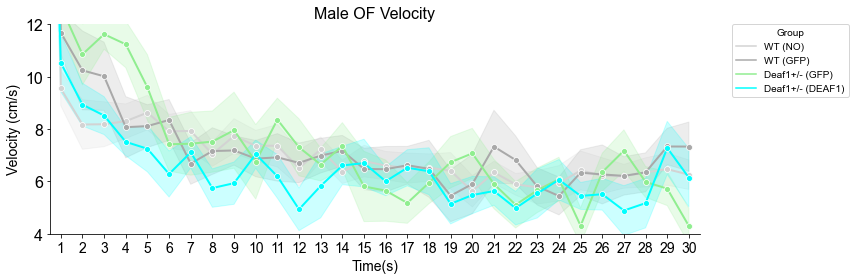

In [17]:
#30 min male
dfmale = dfdeaf1.loc[dfdeaf1.gender == "male"]
df_long = pd.melt(dfmale, id_vars=['level_0','index','mouse', 'type', 'gender', 'geno', 'virus', 'group'], var_name='Time', value_name='Value')
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_long, x='Time', y='Value', hue='group', errorbar="se", marker='o', linewidth=2,
            hue_order =['WT (NO)','WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)'],            
            palette=["lightgray","darkgray", "lightgreen", "cyan"] )

df_long.to_csv("Velocity_in_bins_deaf1_male_plot_30.csv")
# 设置标题和坐标轴
plt.title('Male OF Velocity', fontsize=16)
plt.ylim([4,12])
plt.xlim([0.5,30.5])
plt.xlabel('Time(s)', fontsize=14)
plt.ylabel('Velocity (cm/s)', fontsize=14)
plt.xticks(ticks=range(1, 31)) 
plt.tick_params(axis='x', labelsize=14)
 
plt.tick_params(axis='y', labelsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.grid(False, linestyle='-', alpha=1)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()  # 确保图形不被裁剪
plt.savefig("Velocity_in_bins_deaf1_plot_30.jpg",dpi=300)
plt.savefig("Velocity_in_bins_deaf1_plot_30.pdf",dpi=300)
# plt.close()



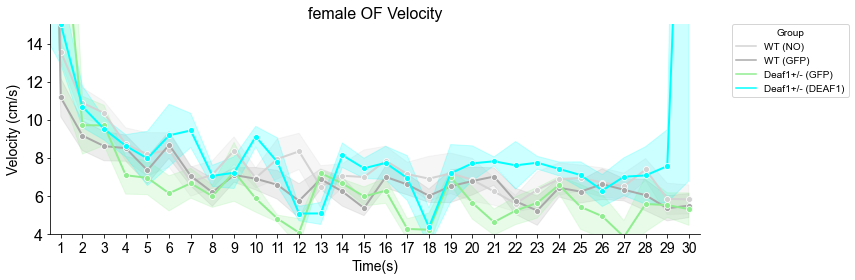

In [20]:
#30 min male
dfmale = dfdeaf1.loc[dfdeaf1.gender == "female"]
df_long = pd.melt(dfmale, id_vars=['level_0','index','mouse', 'type', 'gender', 'geno', 'virus', 'group'], var_name='Time', value_name='Value')
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_long, x='Time', y='Value', hue='group', errorbar="se", marker='o', linewidth=2,
            hue_order =['WT (NO)','WT (GFP)','Deaf1+/- (GFP)', 'Deaf1+/- (DEAF1)'],            
            palette=["lightgray","darkgray", "lightgreen", "cyan"] )

df_long.to_csv("Velocity_in_bins_deaf1_female_plot_30.csv")
# 设置标题和坐标轴
plt.title('female OF Velocity', fontsize=16)
plt.ylim([4,15])
plt.xlim([0.5,30.5])
plt.xlabel('Time(s)', fontsize=14)
plt.ylabel('Velocity (cm/s)', fontsize=14)
plt.xticks(ticks=range(1, 31)) 
plt.tick_params(axis='x', labelsize=14)
 
plt.tick_params(axis='y', labelsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.grid(False, linestyle='-', alpha=1)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()  # 确保图形不被裁剪
plt.savefig("Velocity_in_bins_deaf1_female_plot_30.jpg",dpi=300)
plt.savefig("Velocity_in_bins_deaf1_female_plot_30.pdf",dpi=300)
# plt.close()



In [ ]:
dfin = dfin.reset_index()
dfin["mouse"] = [item.split("_")[0] for item in dfin["index"].tolist()]
dfnew = pd.merge(dfin, dfid, on='mouse', how='outer') 

In [ ]:
dfnew.to_csv("center_in_bins_new.csv",index=False)
dftbr1 = dfnew[dfnew.type == "tbr1"]
dftbr1.to_csv("center_in_bins_tbr1.csv")
dfdeaf1 = dfnew[dfnew.type == "deaf1"]
dfdeaf1.to_csv("center_in_bins_deaf1.csv")

In [ ]:
#30 min male
dfmale = dftbr1.loc[dftbr1.gender == "male"]
df_long = pd.melt(dfmale, id_vars=['index','mouse', 'type', 'gender', 'geno', 'virus', 'group'], var_name='Time', value_name='Value')
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_long, x='Time', y='Value', hue='group', errorbar="se", marker='o', linewidth=2,
            hue_order =['WT (NO)','WT (GFP)','Tbr+/- (GFP)', 'Tbr+/- (TBR1)'],            
            palette=["lightgray","darkgray", "lightgreen", "cyan"] )

df_long.to_csv("center_in_bins_tbr1_male_plot_30.csv")
# 设置标题和坐标轴
plt.title('center time', fontsize=16)
plt.ylim([0,30])
plt.xlim([0.5,30.5])
plt.xlabel('Time(s)', fontsize=14)
plt.ylabel('center time', fontsize=14)
plt.xticks(ticks=range(1, 31)) 
plt.tick_params(axis='x', labelsize=14)
 
plt.tick_params(axis='y', labelsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.grid(False, linestyle='-', alpha=1)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()  # 确保图形不被裁剪
plt.savefig("center_in_bins_tbr1_male_plot_30.jpg",dpi=300)
plt.savefig("center_in_bins_tbr1_male_plot_30.pdf",dpi=300)
# plt.close()



In [ ]:
#30 min female
dffemale = dftbr1.loc[dftbr1.gender == "female"]
df_long = pd.melt(dffemale, id_vars=['index','mouse', 'type', 'gender', 'geno', 'virus', 'group'], var_name='Time', value_name='Value')
plt.figure(figsize=(12, 4))
sns.lineplot(data=df_long, x='Time', y='Value', hue='group', errorbar="se", marker='o', linewidth=2,
            hue_order =['WT (NO)','WT (GFP)','Tbr+/- (GFP)', 'Tbr+/- (TBR1)'],            
            palette=["lightgray","darkgray", "lightgreen", "cyan"] )

df_long.to_csv("center_in_bins_tbr1_female_plot_30.csv")
# 设置标题和坐标轴
plt.title('center time', fontsize=16)
plt.ylim([0,30])
plt.xlim([0.5,30.5])
plt.xlabel('Time(s)', fontsize=14)
plt.ylabel('center time', fontsize=14)
plt.xticks(ticks=range(1, 31)) 
plt.tick_params(axis='x', labelsize=14)
 
plt.tick_params(axis='y', labelsize=16)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.grid(False, linestyle='-', alpha=1)
plt.legend(title='Group', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()  # 确保图形不被裁剪
plt.savefig("center_in_bins_tbr1_female_plot_30.jpg",dpi=300)
plt.savefig("center_in_bins_tbr1_female_plot_30.pdf",dpi=300)
# plt.close()

